<a href="https://colab.research.google.com/github/Fushionek/MLTraining/blob/main/API_ML_Exercises/WeatherPredictionBasedOnKnownModels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

In [2]:
api = 'https://archive-api.open-meteo.com/v1/archive?latitude=52.2297&longitude=21.0122&start_date=2025-01-01&end_date=2025-12-31&daily=temperature_2m_max&timezone=Europe%2FBerlin'

In [3]:
data = requests.get(api).json()

In [4]:
df = pd.DataFrame(data['daily'])

In [5]:
df.head()

,time,temperature_2m_max
0,2025-01-01,6.4
1,2025-01-02,9.1
2,2025-01-03,1.7
3,2025-01-04,-0.8
4,2025-01-05,-3.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   time                365 non-null    object 
 1   temperature_2m_max  365 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.8+ KB


In [7]:
df['time'] = pd.to_datetime(df['time'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   time                365 non-null    datetime64[ns]
 1   temperature_2m_max  365 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.8 KB


In [9]:
df['temp_yesterday'] = df['temperature_2m_max'].shift(1)

In [10]:
df.dropna()

,time,temperature_2m_max,temp_yesterday
1,2025-01-02,9.1,6.4
2,2025-01-03,1.7,9.1
3,2025-01-04,-0.8,1.7
4,2025-01-05,-3.0,-0.8
5,2025-01-06,4.4,-3.0
...,...,...,...
360,2025-12-27,1.3,0.9
361,2025-12-28,2.9,1.3
362,2025-12-29,1.7,2.9
363,2025-12-30,-1.5,1.7


In [11]:
df.isnull().sum()

,0
time,0
temperature_2m_max,0
temp_yesterday,1


In [12]:
df = df.dropna()
print(df.isnull().sum())

time                  0
temperature_2m_max    0
temp_yesterday        0
dtype: int64


In [13]:
X = df[['temp_yesterday']]
y = df['temperature_2m_max']

In [14]:
from sklearn.model_selection import train_test_split

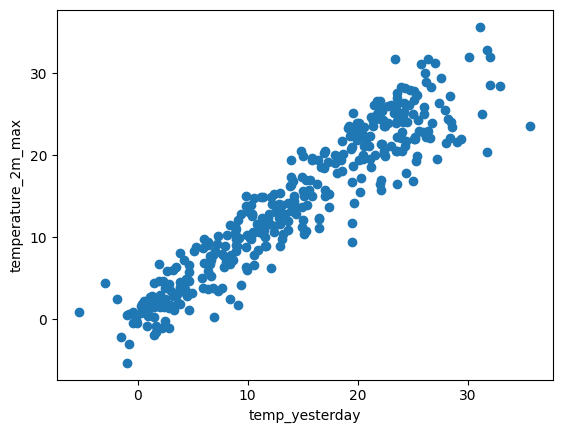

In [15]:
plt.scatter(X,y)
plt.xlabel('temp_yesterday')
plt.ylabel('temperature_2m_max')
plt.show()

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [18]:
model_linear = LinearRegression()
model_linear.fit(X_train, y_train)

#testing on different model type

model_tree = DecisionTreeRegressor(max_depth=4)
model_tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4)

In [19]:
y_pred_linear = model_linear.predict(X_test)
y_pred_tree = model_tree.predict(X_test)

In [20]:
mae_lin = mean_absolute_error(y_test, y_pred_linear)
r2_lin = r2_score(y_test, y_pred_linear)

mae_tree = mean_absolute_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

In [21]:
print(f'Average Error: {mae_lin:.2f} C, Accuracy: {r2_lin:.2f}')
print(f'Average Error: {mae_tree:.2f} C, Accuracy: {r2_tree:.2f}')

Average Error: 1.91 C, Accuracy: 0.75
Average Error: 1.97 C, Accuracy: 0.73


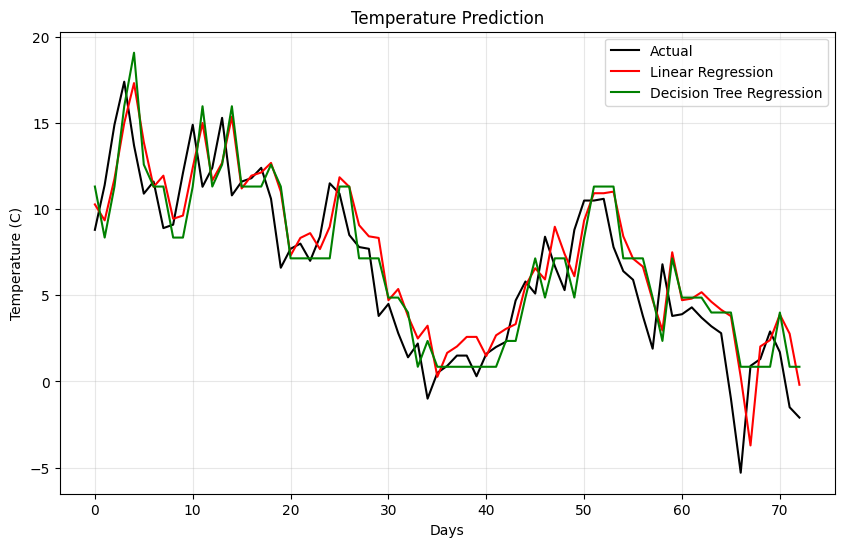

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual', color='black')
plt.plot(y_pred_linear, label='Linear Regression', color='red')
plt.plot(y_pred_tree, label='Decision Tree Regression', color='green')
plt.title('Temperature Prediction')
plt.xlabel('Days')
plt.ylabel('Temperature (C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

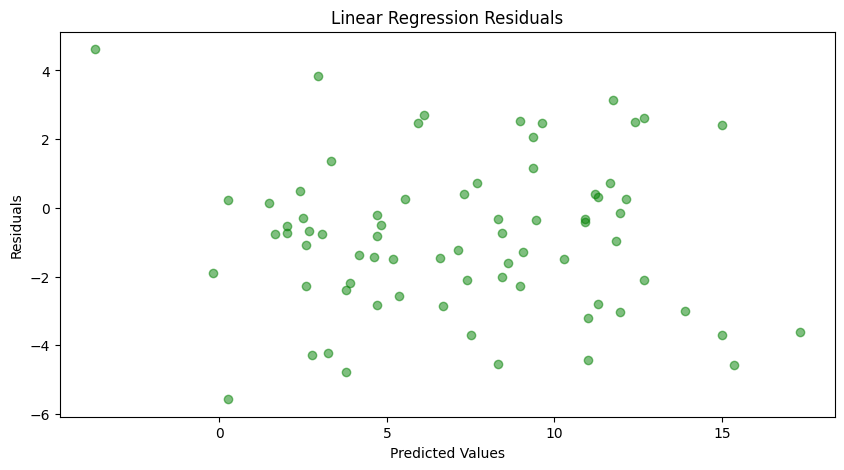

In [23]:
residuals_linear = y_test - y_pred_linear
residuals_tree = y_test - y_pred_tree

plt.figure(figsize=(10,5))
plt.scatter(y_pred_linear, residuals_linear, alpha=0.5, color='green')
plt.title('Linear Regression Residuals')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show(
)

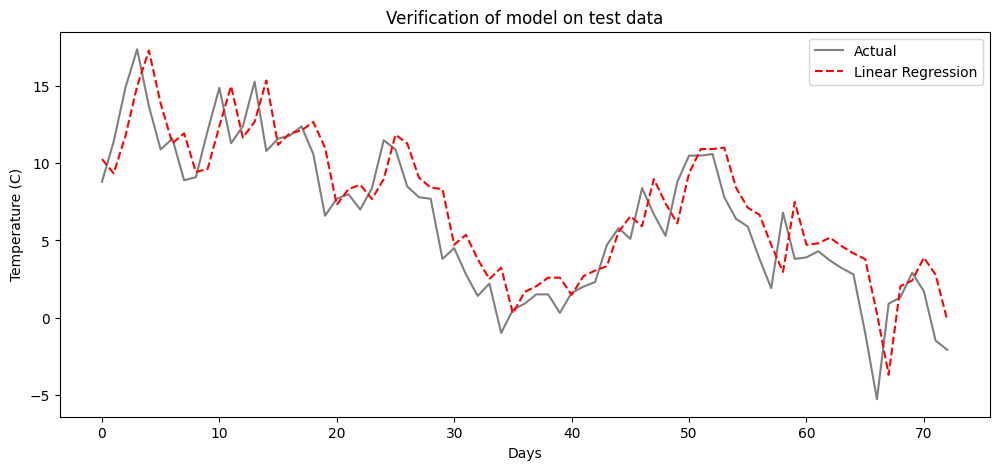

In [24]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual', color='black', alpha=0.5)
plt.plot(y_pred_linear, label='Linear Regression', color='red', linestyle='--')
plt.title('Verification of model on test data')
plt.xlabel('Days')
plt.ylabel('Temperature (C)')
plt.legend()
plt.show()

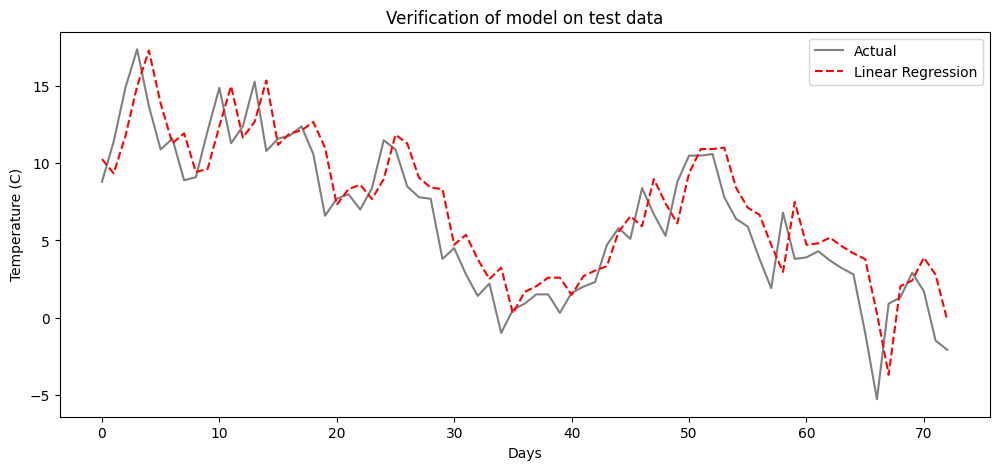

In [25]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual', color='black', alpha=0.5)
plt.plot(y_pred_linear, label='Linear Regression', color='red', linestyle='--')
plt.title('Verification of model on test data')
plt.xlabel('Days')
plt.ylabel('Temperature (C)')
plt.legend()
plt.show()

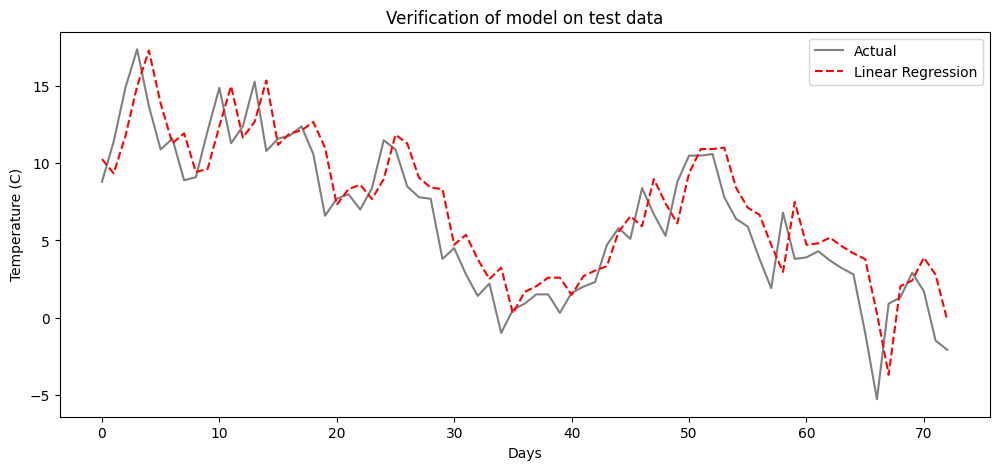

In [26]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual', color='black', alpha=0.5)
plt.plot(y_pred_linear, label='Linear Regression', color='red', linestyle='--')
plt.title('Verification of model on test data')
plt.xlabel('Days')
plt.ylabel('Temperature (C)')
plt.legend()
plt.show()

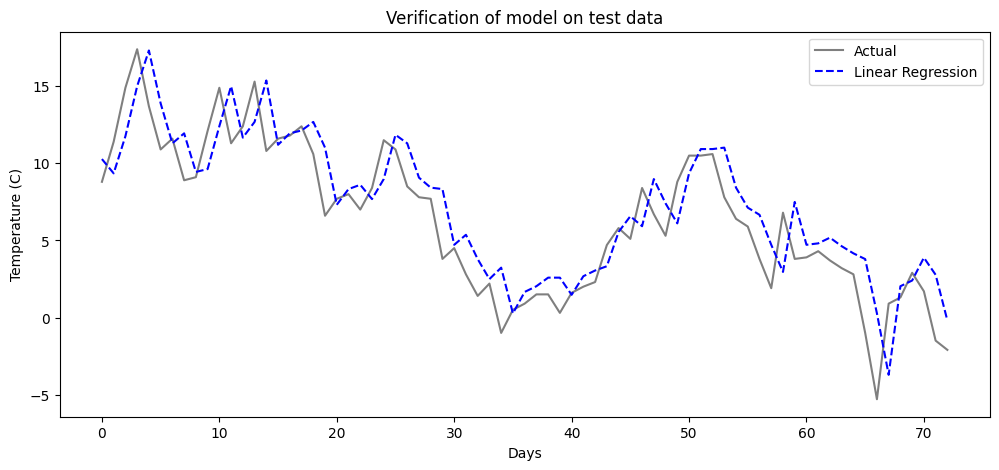

In [27]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual', color='black', alpha=0.5)
plt.plot(y_pred_linear, label='Linear Regression', color='blue', linestyle='--')
plt.title('Verification of model on test data')
plt.xlabel('Days')
plt.ylabel('Temperature (C)')
plt.legend()
plt.show()

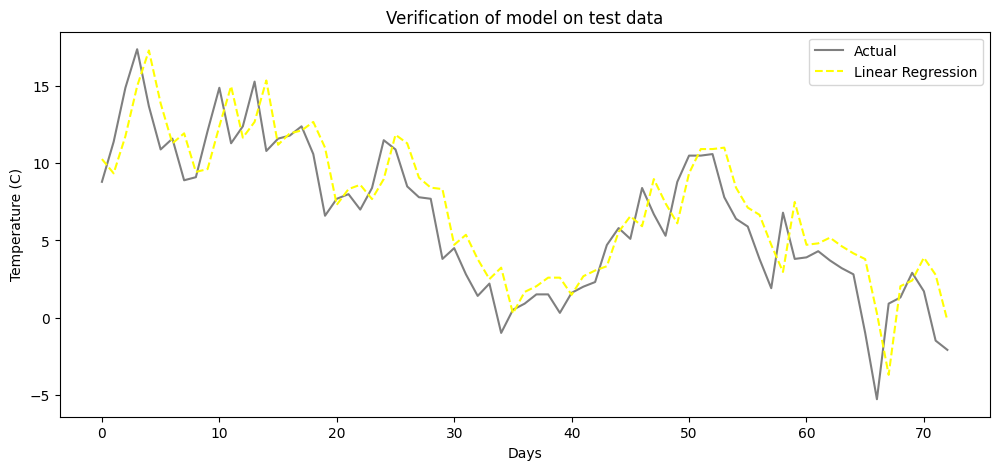

In [28]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual', color='black', alpha=0.5)
plt.plot(y_pred_linear, label='Linear Regression', color='yellow', linestyle='--')
plt.title('Verification of model on test data')
plt.xlabel('Days')
plt.ylabel('Temperature (C)')
plt.legend()
plt.show()

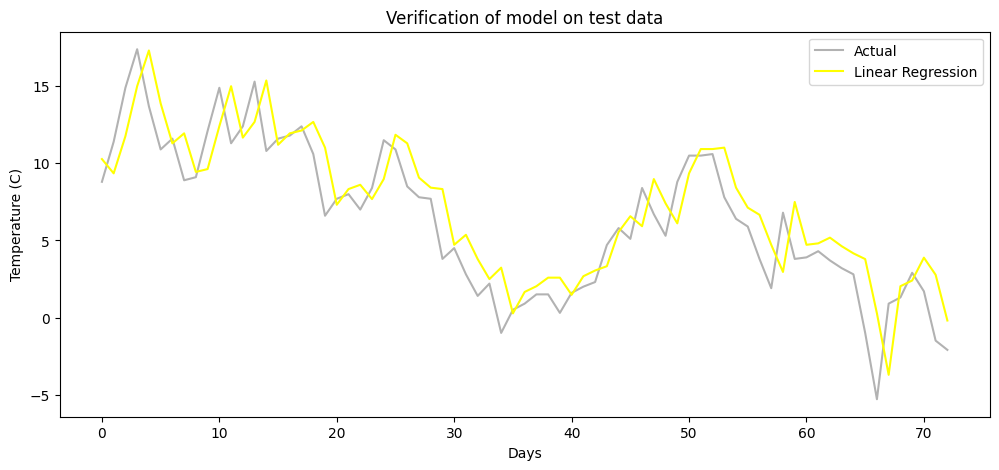

In [30]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual', color='black', alpha=0.3)
plt.plot(y_pred_linear, label='Linear Regression', color='yellow')
plt.title('Verification of model on test data')
plt.xlabel('Days')
plt.ylabel('Temperature (C)')
plt.legend()
plt.show()